<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')

### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [3]:
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [4]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [5]:
housing['sale_date'] = housing['sale_date'].str.replace('EDT','')

In [6]:
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format='%a %b %d %H:%M:%S %Y')
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [7]:
housing['zip'] = housing['zip'].astype(str)
housing.dtypes

street                  str
city                    str
zip                     str
state                   str
beds                  int64
baths                 int64
sq__ft                int64
type                    str
sale_date    datetime64[us]
price                 int64
latitude            float64
longitude           float64
dtype: object

In [8]:
housing.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,985.000000,985.000000,985.000000,985,985.000000,985.000000,985.000000
mean,2.911675,1.776650,1312.918782,2008-05-18 05:12:51.167512,233715.951269,38.445121,-121.193371
min,0.000000,0.000000,-984.000000,2008-05-15 00:00:00,-210944.000000,-121.503471,-121.551704
25%,2.000000,1.000000,950.000000,2008-05-16 00:00:00,145000.000000,38.482704,-121.446119
50%,3.000000,2.000000,1304.000000,2008-05-19 00:00:00,213750.000000,38.625932,-121.375799
75%,4.000000,2.000000,1718.000000,2008-05-20 00:00:00,300000.000000,38.695589,-121.294893
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,38.668433
std,1.307932,0.895371,856.123224,NaN,139088.818896,5.103637,5.100670


<Axes: xlabel='price'>

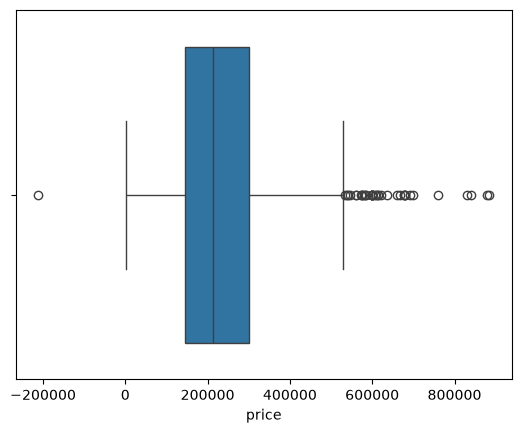

In [9]:
sns.boxplot(data = housing, x = 'price')

In [10]:
housing = housing[housing['price'] > 0]
housing.shape

(984, 12)

In [11]:
housing.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,984.000000,984.000000,984.000000,984,984.000000,984.000000,984.000000
mean,2.913618,1.777439,1315.253049,2008-05-18 05:16:05.853658,234167.841463,38.607670,-121.355832
min,0.000000,0.000000,0.000000,2008-05-15 00:00:00,1551.000000,38.241514,-121.551704
25%,2.000000,1.000000,951.500000,2008-05-16 00:00:00,145000.000000,38.482714,-121.446121
50%,3.000000,2.000000,1304.000000,2008-05-19 00:00:00,214375.000000,38.626257,-121.376010
75%,4.000000,2.000000,1718.500000,2008-05-20 00:00:00,300000.000000,38.695611,-121.295557
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,-120.597599
std,1.307175,0.895484,853.416702,NaN,138434.220875,0.145494,0.138268


<Axes: xlabel='sq__ft'>

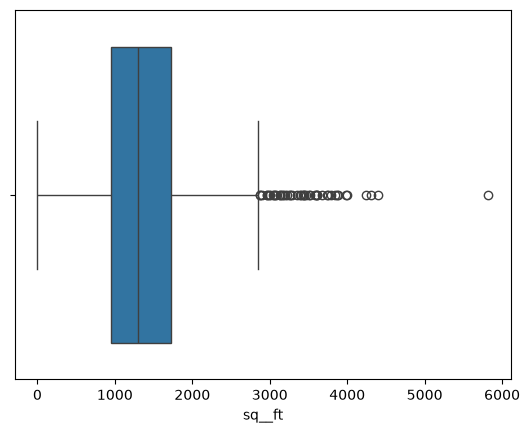

In [12]:
sns.boxplot(data = housing, x = 'sq__ft')

In [13]:
housing = housing[housing['sq__ft'] > 0]
housing.shape

(813, 12)

In [14]:
housing.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,813.000000,813.000000,813.000000,813,813.000000,813.000000,813.000000
mean,3.247232,1.961870,1591.892989,2008-05-18 05:01:06.420664,229471.130381,38.576931,-121.378533
min,1.000000,1.000000,484.000000,2008-05-15 00:00:00,2000.000000,38.241514,-121.550527
25%,3.000000,2.000000,1144.000000,2008-05-16 00:00:00,148750.000000,38.473814,-121.451444
50%,3.000000,2.000000,1419.000000,2008-05-19 00:00:00,207973.000000,38.591618,-121.404999
75%,4.000000,2.000000,1851.000000,2008-05-20 00:00:00,285000.000000,38.674864,-121.325730
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.008159,-120.597599
std,0.849012,0.669367,663.908347,NaN,119897.576889,0.126352,0.119730


In [15]:
housing.to_csv('./data/sacramento_dataframe_after_cleaning.csv', index=False)

When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

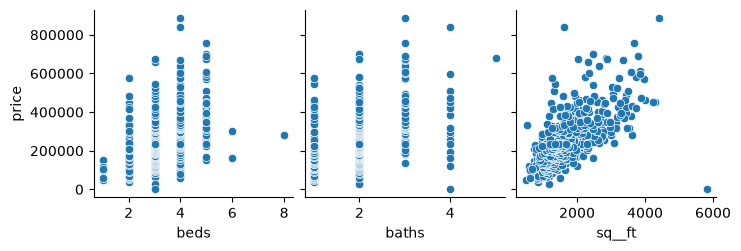

In [16]:
variables = ['beds', 'baths', 'sq__ft']
sns.pairplot(housing, x_vars = variables, y_vars = 'price')

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [17]:
# sq__ft would be the best predictor of Y in the model since there seems to be a linear relation between it and the price

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [18]:
def intercept_slope_function(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    std_x = np.std(x)
    std_y = np.std(y)
    
    cor = np.corrcoef(x, y)[0, 1]
    
    slope = cor * (std_y / std_x)     
    intercept = mean_y - (slope * mean_x) 
    
    return intercept, slope

### 6. Interpret the intercept and the slope.

In [19]:
intercept, slope = intercept_slope_function(housing['sq__ft'], housing['price'])
print("The intercept is: ", intercept)
print("The slope is: ", slope)

The intercept is:  29984.36172651974
The slope is:  125.31418257510143


In [20]:
# slope : For every 1 additional square foot of space, the predicted home price increases by almost $125
# and the intercept is what the price would be if the square feet was 0

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In [21]:
# Prediction Example
# Goal: Estimating a specific outcome.

# Example: An app inputs a house's total size (e.g., 2,000 sq ft) into the model to predict its expected market price (e.g., $350,000) so a seller knows what to list it for.

# Inference Example
# Goal: Understanding relationships between variables.

# Example: A real estate investor examines the model's slope coefficient to learn how much each additional square foot increases a home's value (e.g., +$120 per sq ft), helping them decide if adding an extension is worth the cost.

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

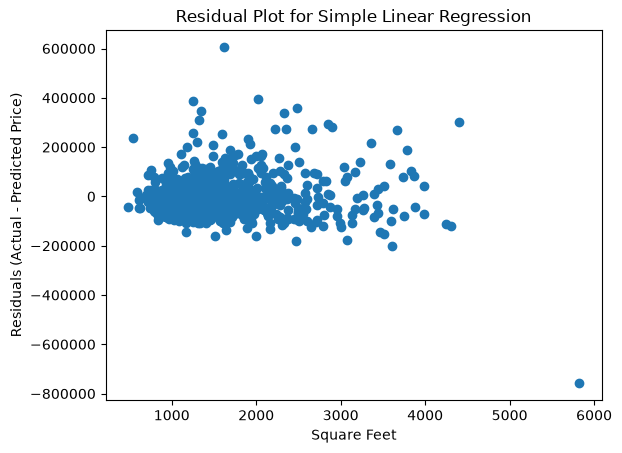

In [22]:
predicted_price = intercept + (slope * housing['sq__ft'])
residuals = housing['price'] - predicted_price

plt.scatter(housing['sq__ft'], residuals);

plt.xlabel('Square Feet')
plt.ylabel('Residuals (Actual - Predicted Price)')
plt.title('Residual Plot for Simple Linear Regression')

plt.show()

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [23]:
housing_dum = pd.get_dummies(housing, columns = ['type'], dtype = int, drop_first = True)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [24]:
housing_dum.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,0,1


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [25]:
features2 = ['beds', 'sq__ft', 'type_Multi-Family', 'type_Residential']
X2 = housing_dum[features2]
y2 = housing_dum['price']

model = LinearRegression()
model.fit(X2, y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-12471.82, 134.97,-20525.73, 33214.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['beds','sq__ft','type_Multi-Family','type_Residential']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.444e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [26]:
y_pred = model.predict(X2)

### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

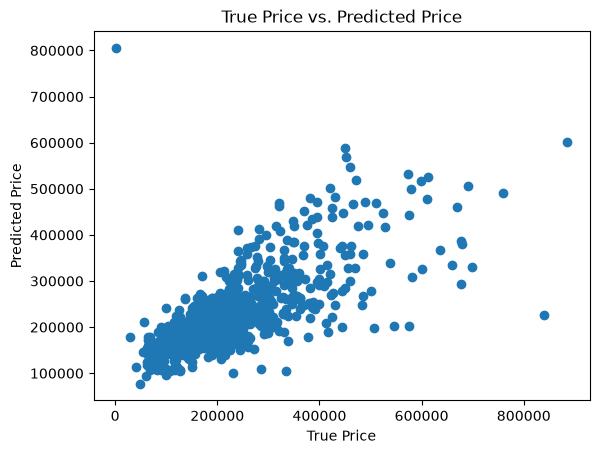

In [27]:
plt.scatter(y2, y_pred)

plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True Price vs. Predicted Price')

plt.show()

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

In [28]:
# Linearity / Independence of Errors / Normality / Equality of Variances / Independence of Predictors
# the first four are the same for a SLR model

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

In [29]:
# linearity : The linearity assumption is mostly met. Most data points follow a clear upward line, showing that a linear model works well for this data. 
# However, there is one major outlier in the top-left corner where a very cheap house was predicted to cost over $800,000.

# Equality of Variances : The equality of variances assumption is not met. The chart shows a clear "funnel" shape. For homes under $200,000, the 
# predictions are close together and accurate. For homes over $400,000, the dots spread out wildly, proving the model is much less reliable for 
# expensive properties.

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [30]:
def r2_adj(r2, n, k):
    return 1 - (((1 - r2) * (n - 1)) / (n - k - 1))

### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [31]:
mse = mean_squared_error(y2, y_pred)

rmse = np.sqrt(mean_squared_error(y2, y_pred))

r2 = r2_score(y2, y_pred)

n = X2.shape[0]
k = X2.shape[1]
adj_r2 = r2_adj(r2, n, k)

print("Mean squared error: ", mse)
print("Root mean squared error: ", rmse)
print("Adjusted R^2: ", adj_r2)

Mean squared error:  7307280436.518891
Root mean squared error:  85482.6323677441
Adjusted R^2:  0.48853708750238023


<!-- The MAE interpretation says what the average real-world mistake looks like in actual dollars.
The RMSE interpretation explains why the error grew and what that means about the model's biggest mistakes (outliers).
The Adjusted R^2 interpretation explains how much of the overall real-world pattern the model actually understood versus what it missed.

the model could be better since R^2 was not close to 1 -->

### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


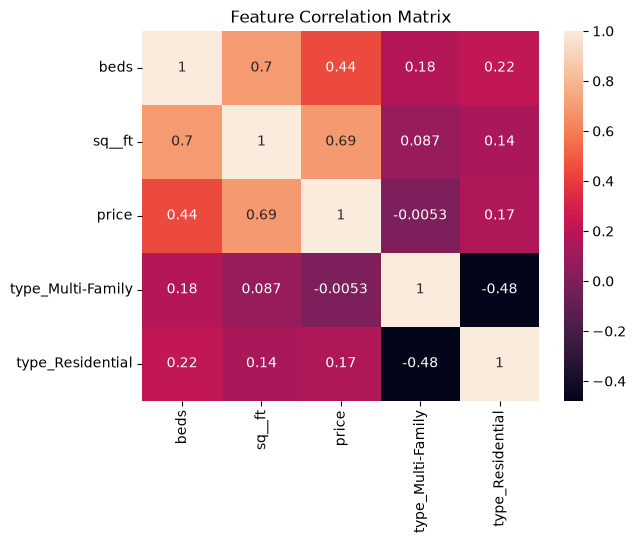

In [32]:
cols = ['beds', 'sq__ft', 'price', 'type_Multi-Family', 'type_Residential']

sns.heatmap(housing_dum[cols].corr(), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [33]:
features3 = ['beds', 'sq__ft', 'type_Residential']
X3 = housing_dum[features3]
y3 = housing_dum['price']

model3 = LinearRegression()
model3.fit(X3, y3)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-13584.82, 135.31, 38869.75]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['beds','sq__ft','type_Residential']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.189e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [34]:
y_pred3 = model3.predict(X3)

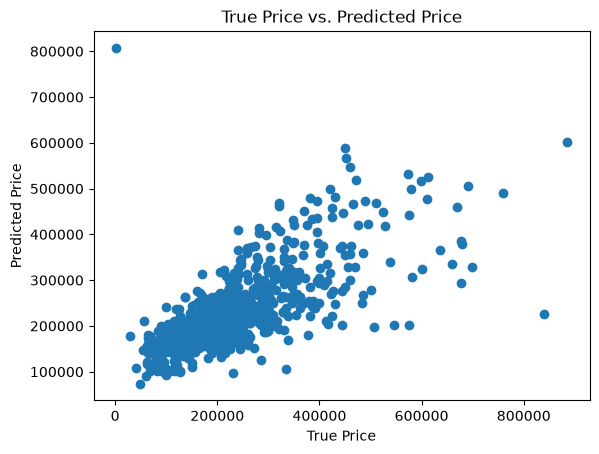

In [35]:
plt.scatter(y3, y_pred3)

plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True Price vs. Predicted Price')

plt.show()

In [36]:
mse3 = mean_squared_error(y3, y_pred3)

rmse3 = np.sqrt(mean_squared_error(y3, y_pred3))

r2_3 = r2_score(y3, y_pred3)

n = X3.shape[0]
k = X3.shape[1]
adj_r2_3 = r2_adj(r2_3, n, k)

print("Mean squared error: ", mse3)
print("Root mean squared error: ", rmse3)
print("Adjusted R^2: ", adj_r2_3)

Mean squared error:  7311784815.955845
Root mean squared error:  85508.97506084286
Adjusted R^2:  0.48885441566111454


In [37]:
# the third model was slightly better ( from 0.4885 to 0.4888)

### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [38]:
city_counts = housing_dum['city'].value_counts()
small_cities = city_counts[city_counts < 20].index

housing_dum['city_grouped'] = housing_dum['city'].replace(small_cities, 'Other')

ohe = OneHotEncoder(sparse_output = False, drop = 'first')
ohe.set_output(transform = 'pandas')

encoded_city_housing_dum = ohe.fit_transform(housing_dum[['city_grouped']])

housing_dum_final = pd.concat([housing_dum, encoded_city_housing_dum], axis = 1)

non_feature_cols = [
    'price', 'street', 'city', 'city_grouped', 
    'zip', 'state', 'sale_date', 'baths'
]

X4 = housing_dum_final.drop(columns = non_feature_cols, errors = 'ignore')
y4 = housing_dum_final['price']

city_model = LinearRegression()
city_model.fit(X4, y4)

y_pred4 = city_model.predict(X4)

r2_4 = r2_score(y4, y_pred4)
rmse4 = np.sqrt(mean_squared_error(y4, y_pred4))

n = X4.shape[0]
k = X4.shape[1]
adj_r2_4 = 1 - ((1 - r2_4) * (n - 1) / (n - k - 1))

print("City Model adjusted R^2: ", adj_r2_4)
print("City Model root mean squared error: ", rmse4)

City Model adjusted R^2:  0.5540030647445939
City Model root mean squared error:  79279.37747150191


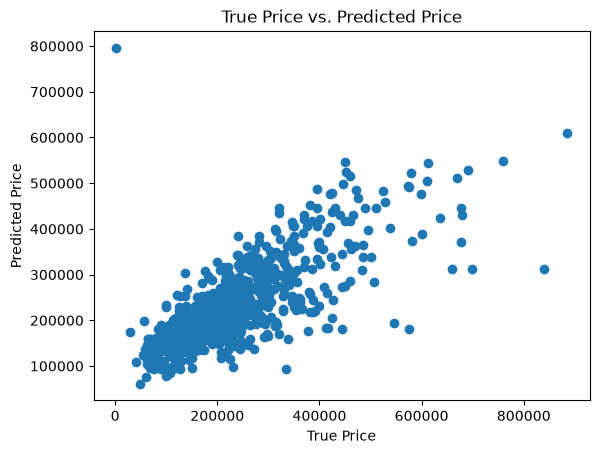

In [39]:
plt.scatter(y4, y_pred4)

plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True Price vs. Predicted Price')

plt.show()

## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X4, y4, test_size = 0.25, random_state = 1)

baseline_guess = y_train.mean()
y_test_baseline = [baseline_guess] * len(y_test)
mae_baseline = mean_absolute_error(y_test, y_test_baseline)

unscaled_model = LinearRegression()
unscaled_model.fit(X_train, y_train)

y_test_pred = unscaled_model.predict(X_test)
mae_model = mean_absolute_error(y_test, y_test_pred)
money_error_saved = mae_baseline - mae_model

print("Baseline MAE: ", mae_baseline)
print("MLR Model MAE: ", mae_model)
print("Average Money Saved per Home: ", money_error_saved)

Baseline MAE:  82727.98572877428
MLR Model MAE:  52278.34652807589
Average Money Saved per Home:  30449.639200698388


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X4.columns)

scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled_df, y_train)

coef_df = pd.DataFrame(
    {
        "Feature": X4.columns,
        "Scaled_Coefficient": scaled_model.coef_,
        "Absolute_Coefficient": abs(scaled_model.coef_),
    }
).sort_values(by = "Absolute_Coefficient", ascending=False)

print(coef_df.head(1))

  Feature  Scaled_Coefficient  Absolute_Coefficient
1  sq__ft         81112.20423           81112.20423


### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [42]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = X4.columns)

y_train_pred = scaled_model.predict(X_train_scaled_df)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = scaled_model.predict(X_test_scaled_df)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Training root mean squared error: ", train_rmse)
print("Testing root mean squared error:  ", test_rmse)
print("Root mean squared error Difference: ", abs(train_rmse - test_rmse))

Training root mean squared error:  81912.25979756247
Testing root mean squared error:   71336.89711091276
Root mean squared error Difference:  10575.362686649707


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

In [43]:
# The Sweet Spot

# No High Variance (No Overfitting): 
# A model with high variance performs well on training data but drastically degrades on unseen test data. In our model, the Testing RMSE ($71,336.90) 
# is actually slightly lower than the Training RMSE ($81,912.26). Because the testing error did not spike, the model did not memorize the training set.

# No High Bias (No Underfitting): 
# A model with high bias performs poorly on both datasets because it is too simple to capture real relationships. Our model successfully captures key 
# trends (like square footage) and significantly improves upon naive guessing—reducing the baseline pricing error by $30,449.62 per home (a ~36.8% 
# improvement).

# Because our model performs well on both sets and maintains balanced error metrics without performance drop-off on unseen data, it achieves the 
# Sweet Spot in the bias-variance tradeoff.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [44]:
ohe_ungrouped = OneHotEncoder(sparse_output=False, drop='first')
encoded_raw_cities = ohe_ungrouped.fit_transform(housing_dum[['city']])

encoded_raw_cities_df = pd.DataFrame(encoded_raw_cities, index=housing_dum.index)

housing_raw_cities = pd.concat([housing_dum, encoded_raw_cities_df], axis=1)

X_raw = housing_raw_cities.drop(columns=non_feature_cols, errors='ignore')
y_raw = housing_raw_cities['price']

X_raw.columns = X_raw.columns.astype(str)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=1
)

overfit_model = LinearRegression()
overfit_model.fit(X_train_raw, y_train_raw)

train_r2_raw = overfit_model.score(X_train_raw, y_train_raw)
test_r2_raw = overfit_model.score(X_test_raw, y_test_raw)

print(f"Train R^2 (Ungrouped Cities): {train_r2_raw:.4f}")
print(f"Test R^2 (Ungrouped Cities):  {test_r2_raw:.4f}")

Train R^2 (Ungrouped Cities): 0.6785
Test R^2 (Ungrouped Cities):  0.6078


In [45]:
# By creating separate categories for rare cities with only 1 or 2 sales, the model starts memorizing those specific homes instead of learning general 
# market trends.Because of this, the model scores higher on the training data, but its performance drops when tested on new properties. This 
# performance gap shows the model is starting to overfit due to adding too many detailed city columns.

### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

In [46]:
# 1. Business Value (The Bottom Line):
# Instead of relying on rough market averages to estimate home values, our predictive model reduces pricing errors by an average of ~$30,450 per 
# house—cutting our valuation mistakes by over 36%. This gives us a major competitive edge in pricing inventory accurately.

# 2. Model Reliability (Low Risk):
# We stress-tested the model on brand-new, unseen property data to ensure it wasn't just 'memorizing' past sales. It performed just as accurately on 
# new data as it did on historical data, meaning it is reliable and ready for real-world business use.

# 3. Key Value Drivers (What Moves the Needle):
# The single biggest factor driving a property's price is usable square footage, followed by location and property condition. While secondary features 
# like extra bedrooms or bathrooms add value, living space size remains the strongest signal for property valuation.